<a href="https://colab.research.google.com/github/Juan-Vega18/-ANALISIS-EXPLOR-DE-DATOS---63510/blob/main/Analisis_regicor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import drive
drive.mount('/mnt/drive')

Drive already mounted at /mnt/drive; to attempt to forcibly remount, call drive.mount("/mnt/drive", force_remount=True).


In [3]:
import os
os.getcwd()
#os.listdir()
os.chdir('/mnt/drive/MyDrive/ciencia_de_datos')
os.listdir()

['netflix_data.csv',
 'democracy_data.csv',
 'democracy_data.gsheet',
 'output_file.csv',
 'regicor.csv']

In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [5]:
df = pd.read_csv('regicor.csv')
df.info()
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2294 entries, 0 to 2293
Data columns (total 24 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        2294 non-null   int64  
 1   year      2294 non-null   int64  
 2   age       2294 non-null   int64  
 3   sex       2294 non-null   object 
 4   smoker    2233 non-null   object 
 5   sbp       2280 non-null   float64
 6   dbp       2280 non-null   float64
 7   histhtn   2286 non-null   object 
 8   txhtn     2251 non-null   object 
 9   chol      2193 non-null   float64
 10  hdl       2225 non-null   float64
 11  triglyc   2231 non-null   float64
 12  ldl       2126 non-null   float64
 13  histchol  2273 non-null   object 
 14  txchol    2239 non-null   object 
 15  height    2259 non-null   float64
 16  weight    2259 non-null   float64
 17  phyact    2206 non-null   float64
 18  pcs       2054 non-null   float64
 19  mcs       2054 non-null   float64
 20  cv        2163 non-null   obje

(2294, 24)

In [6]:
df.head()

,id,year,age,sex,smoker,sbp,dbp,histhtn,txhtn,chol,...,txchol,height,weight,phyact,pcs,mcs,cv,tocv,death,todeath
0,2265,2005,70,Female,Never smoker,138.0,75.0,No,No,294.0,...,No,160.0,64.0,304.200000,54.455,58.918,No,1024.882428,Yes,1299.163435
1,1882,2005,56,Female,Never smoker,139.0,89.0,No,No,220.0,...,No,163.0,67.0,160.300000,58.165,47.995,No,2756.848506,No,39.326294
2,3000105616,2000,37,Male,Current or former < 1y,132.0,82.0,No,No,245.0,...,No,170.0,70.0,552.791209,43.429,62.585,No,1905.968789,No,858.422034
3,3000103485,2000,69,Female,Never smoker,168.0,97.0,No,No,168.0,...,No,147.0,68.0,522.000000,54.325,57.900,No,1055.379623,No,1833.076187
4,3000103963,2000,70,Female,NaN,NaN,NaN,No,No,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Las variables todeath, death, cv, tocv

In [7]:
#Saber cuales son las columnas numericas

num_cols = df.select_dtypes([float, int]).columns
print('Columnas numericas')
print(num_cols)

Columnas numericas
Index(['id', 'year', 'age', 'sbp', 'dbp', 'chol', 'hdl', 'triglyc', 'ldl',
       'height', 'weight', 'phyact', 'pcs', 'mcs', 'tocv', 'todeath'],
      dtype='object')


In [8]:
#Saber cuales son las columnas categoricas

cat_cols = df.select_dtypes('object').columns
print('Columnas categoricas')
print(num_cols)

Columnas categoricas
Index(['id', 'year', 'age', 'sbp', 'dbp', 'chol', 'hdl', 'triglyc', 'ldl',
       'height', 'weight', 'phyact', 'pcs', 'mcs', 'tocv', 'todeath'],
      dtype='object')


In [9]:
#Convertir todas als columnas tipo objeto a category

df[cat_cols] = df[cat_cols].astype('category')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2294 entries, 0 to 2293
Data columns (total 24 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   id        2294 non-null   int64   
 1   year      2294 non-null   int64   
 2   age       2294 non-null   int64   
 3   sex       2294 non-null   category
 4   smoker    2233 non-null   category
 5   sbp       2280 non-null   float64 
 6   dbp       2280 non-null   float64 
 7   histhtn   2286 non-null   category
 8   txhtn     2251 non-null   category
 9   chol      2193 non-null   float64 
 10  hdl       2225 non-null   float64 
 11  triglyc   2231 non-null   float64 
 12  ldl       2126 non-null   float64 
 13  histchol  2273 non-null   category
 14  txchol    2239 non-null   category
 15  height    2259 non-null   float64 
 16  weight    2259 non-null   float64 
 17  phyact    2206 non-null   float64 
 18  pcs       2054 non-null   float64 
 19  mcs       2054 non-null   float64 
 20  cv      

In [10]:
for col in cat_cols:
  print(col)
  print('')
  print(df[col].cat.categories)

sex

Index(['Female', 'Male'], dtype='object')
smoker

Index(['Current or former < 1y', 'Former >= 1y', 'Never smoker'], dtype='object')
histhtn

Index(['No', 'Yes'], dtype='object')
txhtn

Index(['No', 'Yes'], dtype='object')
histchol

Index(['No', 'Yes'], dtype='object')
txchol

Index(['No', 'Yes'], dtype='object')
cv

Index(['No', 'Yes'], dtype='object')
death

Index(['No', 'Yes'], dtype='object')


In [11]:
#PARTE DESCRIPTIVA

df.describe(include='int')
df.describe(include='category')
#print("\n" + "="*60)

,sex,smoker,histhtn,txhtn,histchol,txchol,cv,death
count,2294,2233,2286,2251,2273,2239,2163,2148
unique,2,3,2,2,2,2,2,2
top,Female,Never smoker,No,No,No,No,No,No
freq,1193,1201,1563,1823,1564,2011,2071,1975


3. VALORES FALTANTES

In [12]:
print('\n' + '='*60)
print('Valores faltantes...')
print('='*60)
df['smoker'].isnull().sum()
df.isnull()
df.isnull().sum()


Valores faltantes...


,0
id,0
year,0
age,0
sex,0
smoker,61
sbp,14
dbp,14
histhtn,8
txhtn,43
chol,101


In [13]:
missing = df.isnull().sum()
missing_pct = ((missing/len(df)) * 100).round(2)
missing_df = pd.DataFrame({'Faltantes': missing, 'Porcentaje': missing_pct})
missing_df= missing_df[missing_df['Faltantes'] > 0].sort_values('Porcentaje', ascending=True)
print('\nVariables con valores faltantes: ')
missing_df


Variables con valores faltantes: 


,Faltantes,Porcentaje
histhtn,8,0.35
sbp,14,0.61
dbp,14,0.61
histchol,21,0.92
height,35,1.53
weight,35,1.53
txhtn,43,1.87
txchol,55,2.40
smoker,61,2.66
triglyc,63,2.75


In [14]:
#Analisis por grupos

#print('Analisis por grupos')
st_desc = df.groupby('sex')[num_cols].describe()
print('Estadisticas por sexo', st_desc)

/tmp/ipykernel_21994/1143704177.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  st_desc = df.groupby('sex')[num_cols].describe()


Estadisticas por sexo             id                                                          \
         count          mean           std   min     25%           50%   
sex                                                                      
Female  1193.0  1.184445e+09  1.332220e+09   2.0  2111.0  1.000002e+09   
Male    1101.0  1.249812e+09  1.347204e+09  21.0  2145.0  1.000001e+09   

                                      year               ...         tocv  \
                 75%           max   count         mean  ...          75%   
sex                                                      ...                
Female  3.000102e+09  3.000107e+09  1193.0  2001.454317  ...  2698.118106   
Male    3.000106e+09  3.000109e+09  1101.0  2001.357856  ...  2675.538651   

                    todeath                                                  \
                max   count         mean          std       min         25%   
sex                                                            

In [15]:
#Tabulación cruzada

pd.crosstab(df['sex'], df['smoker'], margins=True)


smoker,Current or former < 1y,Former >= 1y,Never smoker,All
sex,,,,
Female,183,79,900,1162
Male,410,360,301,1071
All,593,439,1201,2233


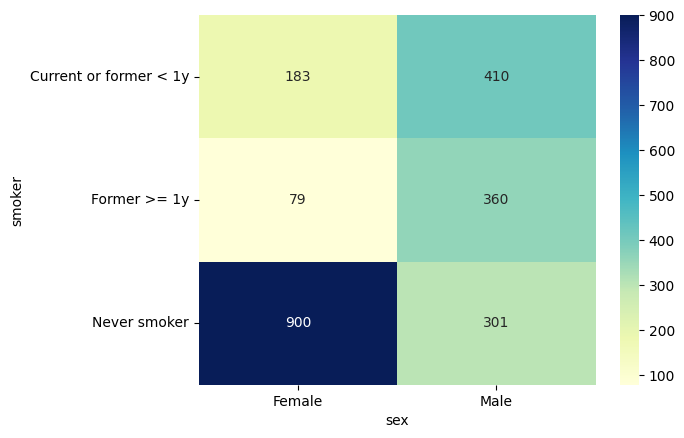

In [16]:
#Graficar

sns.heatmap(pd.crosstab(df['smoker'], df['sex']), annot=True, cmap='YlGnBu', fmt='d')
plt.show()

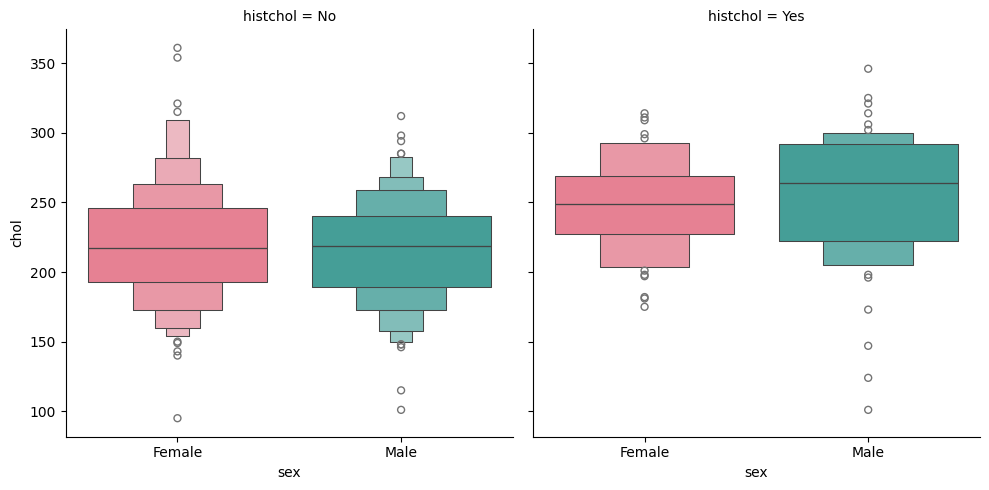

In [17]:
#Forma alternativa con un grafico categorico

sns.catplot(data=df.query('year == 1995'), x='sex', y ='chol', kind='boxen', hue='sex', palette='husl', col ='histchol')
plt.show()